<div style="background-color:#f5f3ff; border-radius:8px; padding:12px; text-align:center;">

# **PRACTICA 2: Juego de Tronos · VISUALIZACIÓN DE DATOS**

</div>

*Visualización de Juego de Tronos*

---

**Grupo:** G-7312  
**Número de pareja:** 01  
**Miembros:**  
- Leire Bernárdez Vázquez  
- Carmen Reiné Rueda


---

### **CONFIGURACIONES PREVIAS**

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Importaciones
</div>

In [18]:
import numpy as np
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import networkx as nx       
import geopandas as gpd      
from folium.plugins import MarkerCluster
from collections import Counter

In [19]:
# === CARGA DE LOS DATOS ===

# Rutas base
ruta_data = r"C:\Users\carme\OneDrive - UAM\Documentos\GitHub\VD_G7312_P02\game_of_thrones\data"
ruta_map = r"C:\Users\carme\OneDrive - UAM\Documentos\GitHub\VD_G7312_P02\GOT-Map\GOT-Map"

# --- Carga de archivos JSON principales ---
with open(os.path.join(ruta_data, "characters.json"), "r", encoding="utf-8") as f:
    characters = json.load(f)

with open(os.path.join(ruta_data, "episodes.json"), "r", encoding="utf-8") as f:
    episodes = json.load(f)

with open(os.path.join(ruta_data, "locations.json"), "r", encoding="utf-8") as f:
    locations = json.load(f)

# --- Carga de archivos GeoJSON (mapas) ---
land = gpd.read_file(os.path.join(ruta_map, "land.geojson"))
places = gpd.read_file(os.path.join(ruta_map, "places.geojson"))

---


### **EJERCICIOS**



### <span >**Parte 1: Visualización de grafos con NetworkX**

En esta primera parte trabajaremos con las relaciones existentes entre los personajes de la serie *Game of Thrones* utilizando la librería **NetworkX**.  
El objetivo es construir el grafo de relaciones, obtener métricas y justificar las decisiones de diseño adoptadas (tipo de grafo, relaciones representadas, tamaño y color de nodos, y layout empleado).


<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 1: Construcción del grafo de relaciones
</div>

A partir del fichero `characters.json`, construiremos un grafo donde los nodos representen personajes y las aristas indiquen algún tipo de relación entre ellos (parentesco, conflicto, etc.).


Antes de construir el grafo, realizamos una exploración básica del fichero para conocer cuántos personajes contiene, si hay registros sin nombre o duplicados, y qué información incluye. También miraremos todas los campos presentes en el dataset para distinguir cuáles son atributos descriptivos (nombre, actor, casa, etc.) y cuáles representan **relaciones entre personajes**.


In [20]:
data_chars = characters["characters"]
print(f"Personajes totales (sin limpieza): {len(data_chars)}")

# ¿Hay personajes SIN nombre?
sin_nombre = [i for i,c in enumerate(data_chars) if not c.get("characterName")]
print("\nSin nombre:", len(sin_nombre))

# ¿Hay nombres duplicados?
contador = Counter([c["characterName"] for c in data_chars if c.get("characterName")])
duplicados = [n for n,c in contador.items() if c>1]
print("\nDuplicados:", len(duplicados))
if duplicados:
    print(duplicados[:])  
    
# Todas los campos posibles en el JSON
todos_los_campos = sorted({k for c in data_chars for k in c.keys()})
print("\nTotal de campos en el JSON:", len(todos_los_campos))
print(todos_los_campos)


Personajes totales (sin limpieza): 389

Sin nombre: 0

Duplicados: 15
['Goldcloak', 'Handmaid', 'High Septon', 'Lannister Captain', 'Little Bird', 'Musician #1', 'Musician #2', 'Musician #3', "Night's Watch Officer", "Night's Watchman", "Night's Watchman #2", 'Red Priestess', 'Septon', 'Stark Guard', 'White Walker']

Total de campos en el JSON: 25
['abducted', 'abductedBy', 'actorLink', 'actorName', 'actors', 'allies', 'characterImageFull', 'characterImageThumb', 'characterLink', 'characterName', 'guardedBy', 'guardianOf', 'houseName', 'killed', 'killedBy', 'kingsguard', 'marriedEngaged', 'nickname', 'parentOf', 'parents', 'royal', 'servedBy', 'serves', 'sibling', 'siblings']


que haga un merge para comprobar lso duplicados

Estos personajes duplicados no son errores, sino roles genéricos o figurantes sin relevancia narrativa.  
Posteriormente se eliminarán para simplificar el grafo y centrarnos en los personajes principales.  


**1. Explora los tipos de relaciones disponibles en el fichero y selecciona al menos tres ipos diferentes para incluir en el grafo.**

El dataset contiene 25 campos diferentes, hemos seleccionado únicamente aquellos campos que representan vínculos entre personajes (por ejemplo: parents, parentOf, siblings, killed, killedBy, marriedEngaged, etc.).  
El resto de atributos descriptivos (como characterName, actorName, houseName, etc.) se mantendrán solo si aportan información adicional en el grafo.

In [21]:
# Campos que consideramos "de relación" según el JSON real
relaciones_validas = {
    "parents", "parentOf", "siblings", "sibling",
    "killed", "killedBy",
    "marriedEngaged",
    "servedBy", "serves",
    "guardianOf", "guardedBy",
    "allies", "abducted", "abductedBy"
}

# Las que son realmente relaciones
relaciones_personajes = sorted({k for k in todos_los_campos if k in relaciones_validas})
print("\nSolo las campos que son relaciones válidas:", len(relaciones_personajes))
print("Tipos de relaciones presentes:", relaciones_personajes)




Solo las campos que son relaciones válidas: 14
Tipos de relaciones presentes: ['abducted', 'abductedBy', 'allies', 'guardedBy', 'guardianOf', 'killed', 'killedBy', 'marriedEngaged', 'parentOf', 'parents', 'servedBy', 'serves', 'sibling', 'siblings']


**Limpieza del dataset: eliminación de duplicados y columnas no necesarias**

Antes de construir el grafo, realizamos una limpieza del dataset para eliminar:

- Personajes genéricos o duplicados, que no aportan relaciones significativas.
- Columnas que no son relevantes para la práctica, como los enlaces de actor o las imágenes, ya que no influyen en la estructura del grafo.

Dejaremos únicamente los campos necesarios para representar nodos y relaciones válidas .

In [22]:
# Personajes genéricos o repetidos
nombres_duplicados = 'Goldcloak', 'Handmaid', 'High Septon', 'Lannister Captain', 'Little Bird', 'Musician #1', 'Musician #2', 'Musician #3', "Night's Watch Officer", "Night's Watchman", "Night's Watchman #2", 'Red Priestess', 'Septon', 'Stark Guard', 'White Walker'

# Campos relevantes: nombre, casa, estatus real y relaciones útiles
campos = ['characterName', 'houseName', 'royal', "kingsguard", "nickname"]

campos_utiles = campos + relaciones_personajes

# Crear nuevo dataset filtrado
data_chars_limpio = []

for c in data_chars:
    nombre = c.get("characterName")
    # Saltamos los personajes duplicados o sin nombre
    if not nombre or nombre in nombres_duplicados:
        continue

    # Conservamos solo las columnas útiles (atributos + relaciones)
    limpio = {k: c[k] for k in campos_utiles if k in c}
    data_chars_limpio.append(limpio)

print(f"Personajes antes de limpiar: {len(data_chars)}")
print(f"Personajes después de limpiar: {len(data_chars_limpio)}")

# Comprobamos algunos campos del primer registro limpio
print("\nEjemplo de estructura limpia:")
for k, v in data_chars_limpio[1].items():
    print(f"- {k}: {v }")

Personajes antes de limpiar: 389
Personajes después de limpiar: 355

Ejemplo de estructura limpia:
- characterName: Aegon Targaryen
- houseName: Targaryen
- royal: True
- killedBy: ['Gregor Clegane']
- parents: ['Elia Martell', 'Rhaegar Targaryen']
- siblings: ['Rhaenys Targaryen', 'Jon Snow']


El archivo limpio se guarda como `characters_clean.json` y servirá como base para el resto de la práctica.


In [23]:
# === GUARDAR EL NUEVO JSON LIMPIO ===
ruta_salida = os.path.join(ruta_data, "characters_clean.json")

with open(ruta_salida, "w", encoding="utf-8") as f:
    json.dump(data_chars_limpio, f, ensure_ascii=False, indent=3)

print(f"\nArchivo limpio guardado correctamente en:\n{ruta_salida}")
print(f"Total de personajes guardados: {len(data_chars_limpio)}")



Archivo limpio guardado correctamente en:
C:\Users\carme\OneDrive - UAM\Documentos\GitHub\VD_G7312_P02\game_of_thrones\data\characters_clean.json
Total de personajes guardados: 355


**2. Decide qué relaciones deben representarse como dirigidas y cuáles como no 
dirigidas**

In [24]:
# === CARGA DEL JSON LIMPIO ===
ruta_clean = os.path.join(ruta_data, "characters_clean.json")
with open(ruta_clean, "r", encoding="utf-8") as f:
    personajes = json.load(f)

# === DETECTAMOS RELACIONES PRESENTES Y SU FRECUENCIA ===
rel_counter = Counter()

for c in personajes:
    for k, v in c.items():
        if isinstance(v, list): 
            rel_counter[k] += len(v)

print("\nTipos de relaciones encontradas y su frecuencia total:")
for rel, n in rel_counter.most_common():
    print(f"- {rel}: {n}")

# Cuántos personajes tienen al menos una relación
personajes_con_rel = sum(
    any(isinstance(v, list) and len(v) > 0 for v in c.values())
    for c in personajes
)
print(f"\nPersonajes con al menos una relación: {personajes_con_rel}")



Tipos de relaciones encontradas y su frecuencia total:
- killed: 221
- killedBy: 203
- siblings: 134
- parents: 81
- parentOf: 78
- marriedEngaged: 55
- serves: 22
- guardianOf: 15
- guardedBy: 12
- servedBy: 10
- houseName: 10
- allies: 8
- sibling: 2
- abductedBy: 1
- abducted: 1

Personajes con al menos una relación: 226


A partir del análisis de frecuencias realizado, observamos que hay relaciones principales y otras aparecen con poca frecuencia y no aportan una estructura suficientemente rica para el grafo general.

Basándonos en estos resultados y en los ejemplos comentados en clase, hemos decidido centrarnos en **tres tipos de relaciones significativas**:
- **killed** → relación dirigida, representa un conflicto donde un personaje mata a otro (A → B).  
- **siblings** → relación no dirigida, representa vínculos de hermandad mutua.  
- **parents** → relación no dirigida, representa lazos familiares entre padres e hijos sin sentido de dirección.

De este modo, construiremos un **grafo mixto**, ya que combina relaciones **dirigidas** (de conflicto)  y **no dirigidas** (de tipo familiar o de parentesco), reflejando tanto los enfrentamientos como los lazos de sangre entre los personajes.



**3. Crea el grafo en NetworkX, añadiendo atributos a las aristas que indiquen el tipo de 
relación.**

En este apartado construiremos el grafo de relaciones a partir del archivo characters_clean.json.

Cada **nodo** representará un personaje,  y cada **arista** una relación entre dos personajes (conflicto, hermandad o parentesco).

In [25]:
# === CREAR GRAFO MIXTO ===
G = nx.Graph()  # permite direccionalidad mixta (dirigida y no dirigida simulada)

# === AÑADIR NODOS ===
for p in personajes:
    nombre = p["characterName"]
    G.add_node(nombre, house=p.get("houseName"), royal=p.get("royal"))

# === AÑADIR RELACIONES DIRIGIDAS (killed) ===
for p in personajes:
    origen = p["characterName"]
    if "killed" in p:
        for destino in p["killed"]:
            if destino != origen:
                G.add_edge(origen, destino, relation="killed", directed=True)

# === AÑADIR RELACIONES NO DIRIGIDAS (siblings, parents) ===
for p in personajes:
    origen = p["characterName"]
    for tipo in ["siblings", "parents"]:
        if tipo in p:
            for destino in p[tipo]:
                if destino != origen:
                    # Añadimos dos direcciones opuestas para simular una arista no dirigida
                    G.add_edge(origen, destino, relation=tipo, directed=False)
                    G.add_edge(destino, origen, relation=tipo, directed=False)

# === RESUMEN ===
print(f"Nodos totales: {G.number_of_nodes()}")
print(f"Aristas totales: {G.number_of_edges()}")

tipos_rel = [d["relation"] for _, _, d in G.edges(data=True)]
for rel, n in Counter(tipos_rel).items():
    print(f"- {rel}: {n}")

Nodos totales: 408
Aristas totales: 357
- killed: 205
- siblings: 71
- parents: 81


>❓ **Duda para el profesor:**  
>
>En el dataset aparecen casos como el de `Janos Slynt`, que incluye la relación `"killed": ["Barra"]`,  
>pero *Barra* no figura como personaje en el JSON (no tiene `characterName` ni relaciones propias).  
>
>¿Debemos considerar este tipo de menciones ("Barra", "Faith Militant", "Roof collapse", etc.)  
>como **relaciones válidas** dentro del grafo (aunque generen nodos sin atributos),  
>o deben eliminarse al tratarse de **entidades narrativas no definidas** (eventos, grupos o víctimas sin presencia individual)?  


In [26]:
# Todos los nombres originales
nombres_originales = {p["characterName"] for p in personajes}

# Nodos añadidos automáticamente
nodos_extra = [n for n in G.nodes if n not in nombres_originales]

print(f"Nodos totales en el grafo: {G.number_of_nodes()}")
print(f"Personajes originales: {len(nombres_originales)}")
print(f"Nodos adicionales detectados: {len(nodos_extra)}")

if nodos_extra:
    print("Ejemplos de nodos adicionales:", nodos_extra[:])

# --- (Opcional) Eliminar los nodos inválidos ---
# ----------------------------------------------------------
# Descomentar si el profesor confirma que deben eliminarse:
#
# G.remove_nodes_from(nodos_extra)
# print(f"\nNodos después de limpiar: {G.number_of_nodes()}")
# print(f"Aristas después de limpiar: {G.number_of_edges()}")
# Contar aristas por tipo
# rel_por_tipo = Counter(nx.get_edge_attributes(G, 'relation').values())

# print("Distribución de aristas por tipo de relación:")
# for tipo, n in rel_por_tipo.items():
#    print(f"- {tipo}: {n}")
# ----------------------------------------------------------


Nodos totales en el grafo: 408
Personajes originales: 355
Nodos adicionales detectados: 53
Ejemplos de nodos adicionales: ['Frey Soldier #1', 'Ghita', 'White Walker', 'Soldier Tom', 'Bolton Officer', 'Oznak zo Pahl', 'Iggo', 'Khal Brozho', 'Khal Qorro', 'Khal Forzho', 'Eleanor', "Eleanor's Daughter", 'Zalla', 'Kevin Eldon', 'Laurence Spellman', "King's Landing Boaster", 'Faith Militant', 'Rennick', 'Belicho Paenymion', 'Torrhen Karstark', 'Barra', 'Despondent Man', 'Norvoshi Pit Fighter', 'Meereenese Champion', 'Donnel Hill', 'Cooper', 'Axell Florent', 'Son of the Harpy', 'Bolton Soldier', 'Master Torturer', 'Medger Cerwyn', 'Lady Cerwyn', 'Unidentified Cerwyn', 'Old Woman', 'Kings Landing Rioter #1', 'Kings Landing Rioter #2', 'Kings Landing Rioter #3', 'Frey Soldier #2', 'Lowell', 'Dying Man', 'Steve', 'Riddell', 'Morgan', 'Gordy', 'Simpson', "Olly's Mother", 'Tortured Prisoner', 'Harrag', 'Maester Caleotte', 'Old Man', 'Guymon', "Mole's Town Whore", 'Catelyn Tully']


El grafo resultante integra los tres tipos de relaciones seleccionadas (killed, siblings y parents),combinando vínculos dirigidos (conflictos) y no dirigidos (familiares).

Nodos totales: 408
De ellos, 355 corresponden a personajes reales del dataset original y 53 son nodos adicionalesque aparecen en las relaciones pero no figuran como personajes definidos (por ejemplo: Barra, Faith Militant, Roof collapse…).
Estos nodos podrían considerarse entidades narrativas sin atributos propios.

Aristas totales: 647
La mayoría de las conexiones provienen de vínculos familiares (siblings y parents), mientras que las relaciones de conflicto (killed) aportan una red más dispersa.
Esta diferencia refleja la importancia de las casas y linajes frente a los enfrentamientos individuales.

En conjunto, el grafo describe una red coherente donde los lazos de sangre y los actos de violencia estructuran gran parte de las conexiones entre personajes.

**La posible eliminación de los nodos “no definidos” queda pendiente de confirmación por parte del profesor.**

**4. Realiza una primera visualización del grafo completo, diferenciando visualmente 
los tipos de relaciones mediante colores o estilos de línea.**

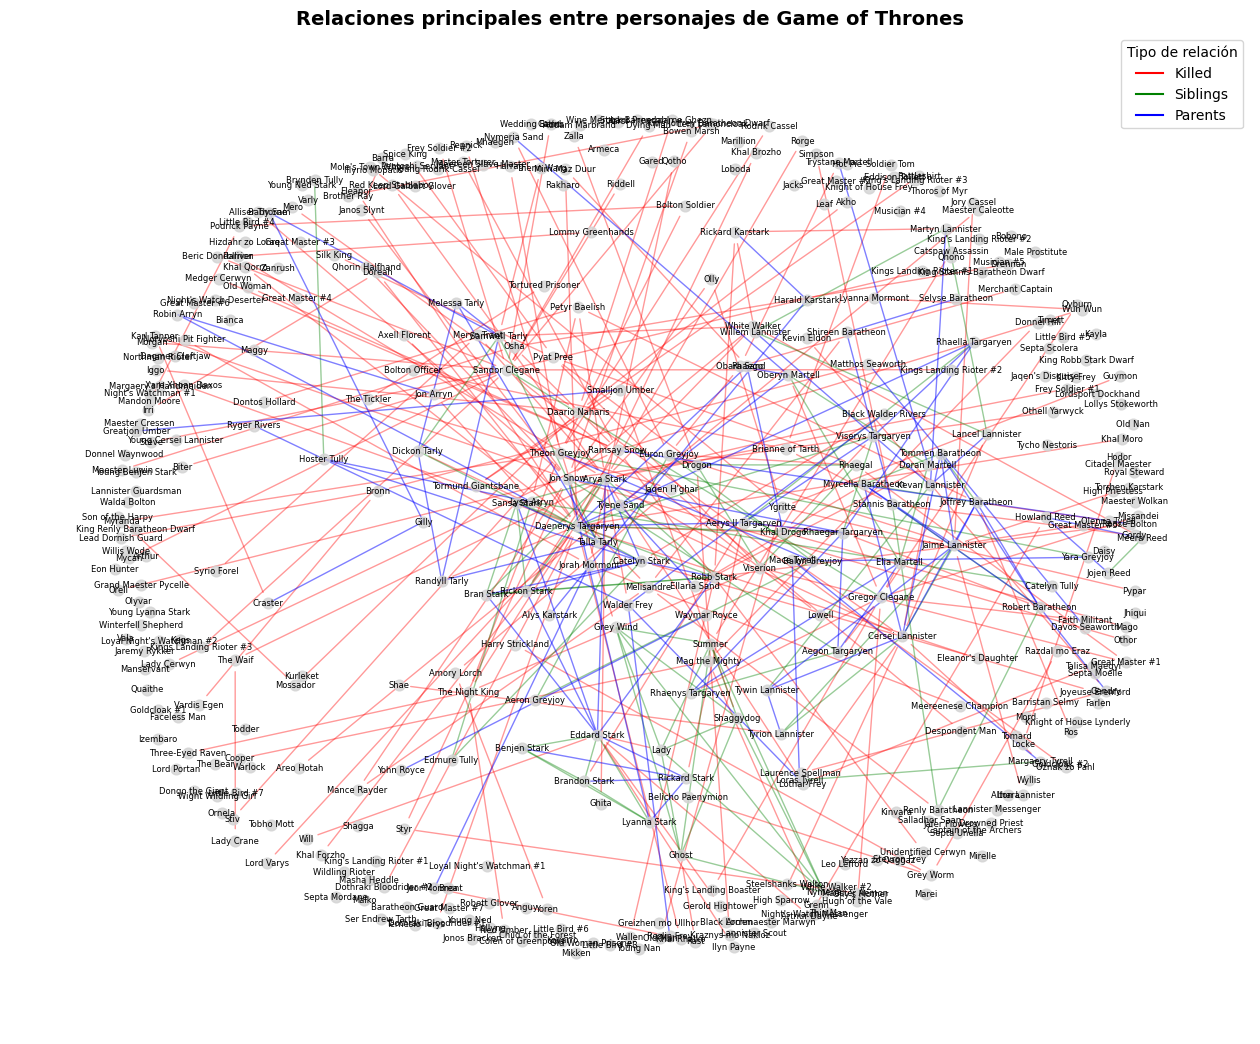

In [27]:
# === CONFIGURACIÓN DE COLORES Y LAYOUT ===

# Calculamos posiciones para los nodos (layout)
pos = nx.spring_layout(G, k=0.5, seed=42) # k controla la distancia media entre nodos; seed da estabilidad al gráfico

# Creamos listas de aristas separadas por tipo para dibujarlas con distinto color
edges_killed = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "killed"]
edges_siblings = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "siblings"]
edges_parents = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "parents"]

# === VISUALIZACIÓN INICIAL DEL GRAFO ===
plt.figure(figsize=(16, 13))
plt.title("Relaciones principales entre personajes de Game of Thrones", fontsize=14, fontweight='bold')

# Dibujamos nodos (mismo tamaño por ahora)
nx.draw_networkx_nodes(G, pos, node_size=60, node_color="lightgray", alpha=0.8)

# Dibujamos aristas por tipo de relación
nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.4, arrows=False)
nx.draw_networkx_edges(G, pos, edgelist=edges_parents, edge_color="blue", alpha=0.5, arrows=False)

# Añadimos algunos nombres de personajes (uno de cada 35 nodos)
nx.draw_networkx_labels(G, pos, font_size=6, font_color="black")

import matplotlib.lines as mlines
legend_handles = [
    mlines.Line2D([], [], color='red', label='Killed'),
    mlines.Line2D([], [], color='green', label='Siblings'),
    mlines.Line2D([], [], color='blue', label='Parents')
]
plt.legend(handles=legend_handles, title="Tipo de relación", loc="upper right")

plt.axis("off")
plt.show()



En este primer gráfico se representa el conjunto completo de personajes y relaciones seleccionadas

Cada tipo de relación se ha diferenciado visualmente por color:
- 🔴 **Killed** → relaciones de conflicto (dirigidas)
- 🟢 **Siblings** → lazos de hermandad (no dirigidas)
- 🔵 **Parents** → vínculos de parentesco (no dirigidas)

Se ha empleado el layout **spring_layout**, que equilibra la distancia entre nodos para facilitar la lectura de la red.  
Los nodos con mayor número de conexiones tienden a situarse en el centro, mostrando las familias más relevantes de la serie.
  
Esta primera visualización permite observar la estructura general de la red antes de aplicar criterios más detallados.

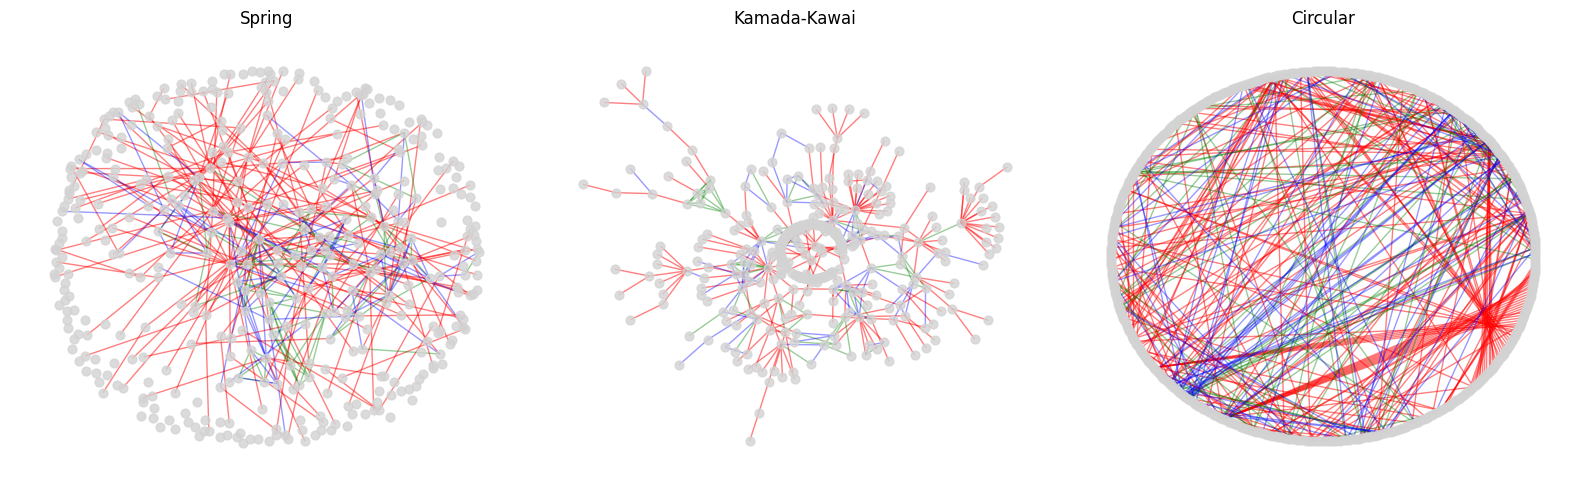

In [28]:
# === COMPARACIÓN DE LAYOUTS ===
layouts = {
    "Spring": nx.spring_layout(G, k=0.4, seed=42),
    "Kamada-Kawai": nx.kamada_kawai_layout(G),
    "Circular": nx.circular_layout(G)
}

plt.figure(figsize=(16, 5))
for i, (name, pos_i) in enumerate(layouts.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(name, fontsize=12)
    nx.draw_networkx_nodes(G, pos_i, node_size=40, node_color="lightgray", alpha=0.8)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_killed, edge_color="red", alpha=0.5)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_siblings, edge_color="green", alpha=0.4)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_parents, edge_color="blue", alpha=0.4)
    plt.axis("off")
plt.tight_layout()
plt.show()


**5. Ajusta el tamaño de los nodos en función del número total de relaciones de cada personaje (grado).**

In [29]:
# Calculamos grado
grados = dict(G.degree())

# Escalamos para el tamaño (multiplicamos por un factor)
node_sizes = [grados[n] * 10 for n in G.nodes()]

In [30]:
# === CARGA DEL JSON DE GRUPOS ===
with open(os.path.join(ruta_data, "characters-groups.json"), "r", encoding="utf-8") as f:
    grupos_data = json.load(f)["groups"]

# Creamos un diccionario personaje → color según grupo
colores = {
    "Stark": "#1E90FF",
    "Lannister": "#E41A1C",
    "Targaryen": "#FF7F00",
    "Baratheon": "#FFD700",
    "Tyrell": "#4DAF4A",
    "Greyjoy": "#984EA3",
    "Martell": "#FF69B4",
    "Night's Watch": "#555555",
    "Dothraki": "#A0522D",
    "Wildlings": "#00CED1",
    "Otros": "#C0C0C0"
}

# Diccionario personaje → color
color_por_personaje = {}
for g in grupos_data:
    color = colores.get(g["name"], colores["Otros"])
    for p in g["characters"]:
        color_por_personaje[p] = color

# Asignamos color a cada nodo del grafo
node_colors = [color_por_personaje.get(n, colores["Otros"]) for n in G.nodes()]


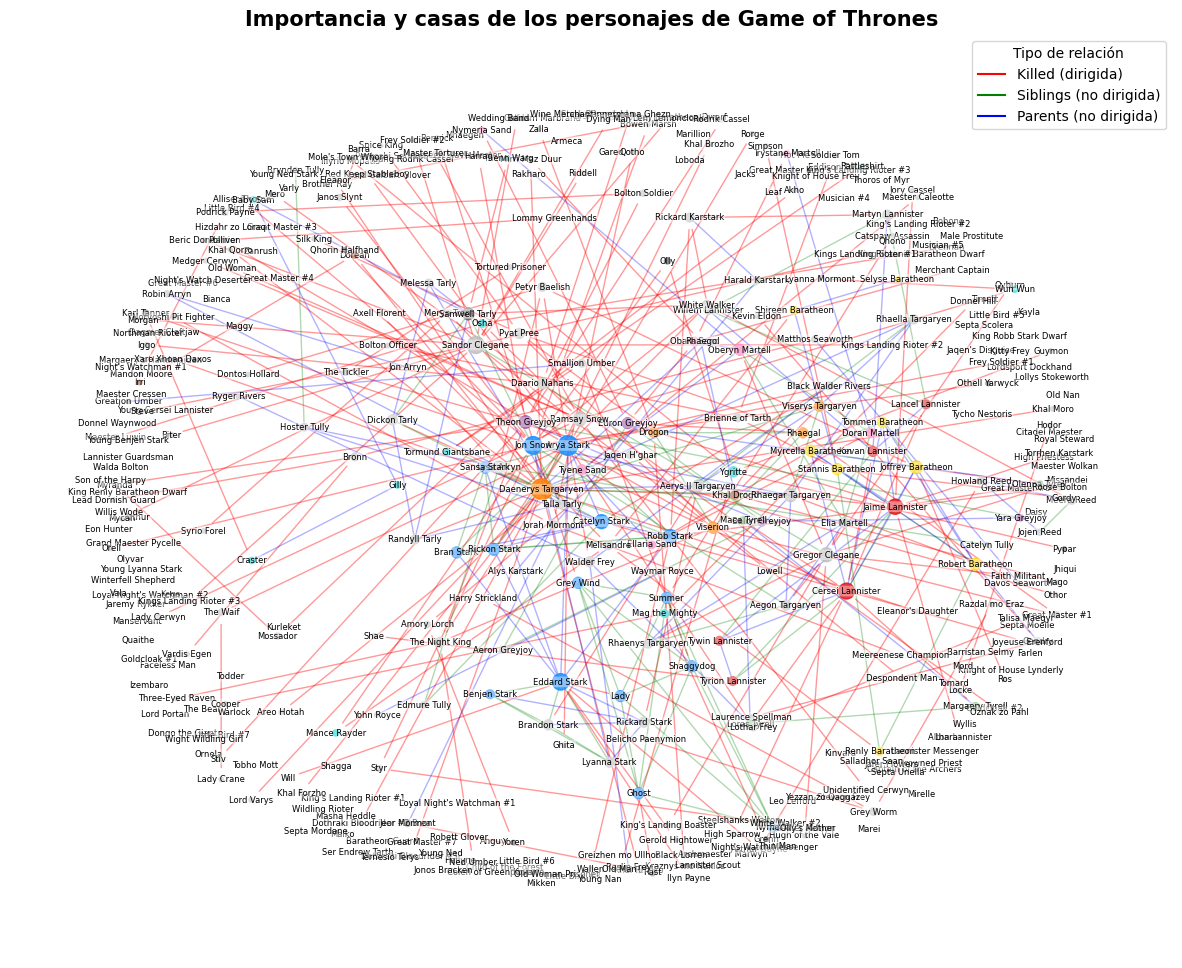

In [31]:
plt.figure(figsize=(15, 12))
plt.title("Importancia y casas de los personajes de Game of Thrones", fontsize=15, fontweight="bold")

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.85
)

nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.3)
nx.draw_networkx_edges(G, pos, edgelist=edges_parents, edge_color="blue", alpha=0.3)

nx.draw_networkx_labels(
    G, pos,
    font_size=6,
    font_color="black",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none", boxstyle="round,pad=0.1")
)

# Leyenda
import matplotlib.lines as mlines
legend_handles = [
    mlines.Line2D([], [], color='red', label='Killed (dirigida)', linewidth=1.5),
    mlines.Line2D([], [], color='green', label='Siblings (no dirigida)', linewidth=1.5),
    mlines.Line2D([], [], color='blue', label='Parents (no dirigida)', linewidth=1.5)
]
plt.legend(handles=legend_handles, title="Tipo de relación", loc="upper right")

plt.axis("off")
plt.show()


En este apartado se ha ajustado el **tamaño de los nodos** en función del **grado de cada personaje**, es decir, del número total de relaciones que mantiene dentro del grafo.

De este modo:
- Los personajes con **más conexiones** (ya sea por parentesco, hermandad o conflictos) aparecen con un tamaño mayor.
- Los personajes secundarios, con pocas o ninguna relación, se muestran con nodos más pequeños y periféricos.

Además, se ha añadido un esquema de **colores por casa o grupo** a partir del archivo `characters-groups.json`, 
lo que permite identificar visualmente las alianzas y vínculos familiares más relevantes:

| Color | Casa o grupo |
|:------|:--------------|
| 🔴 Rojo | Lannister |
| 🟠 Naranja | Targaryen |
| 🟡 Amarillo | Baratheon |
| 🟢 Verde | Tyrell |
| 🔵 Azul | Stark |
| ⚫ Gris oscuro | Night’s Watch |
| 🟤 Marrón | Dothraki |
| 🟣 Morado | Greyjoy |
| 🌿 Verde lima | Martell |
| ⚪ Gris claro | Otros / secundarios |

El resultado permite observar cómo las **casas más influyentes** (Stark, Lannister, Targaryen) concentran los nodos más grandes y las mayores interconexiones.  
En cambio, los personajes menores o aislados aparecen dispersos en los bordes del grafo, evidenciando su menor relevancia dentro de la red.

En esta versión final del grafo se ha mejorado la legibilidad visual:
- Se ha utilizado una paleta de colores con mayor contraste, adaptada para distinguir las principales casas.
- Los nodos sin grupo se muestran en **gris claro con borde negro**, evitando que desaparezcan en el fondo.
- Se ha añadido un fondo blanco translúcido a las etiquetas para facilitar su lectura sobre nodos de color intenso.


**Después de realizar el gráfico, responde brevemente:** 

**• ¿Qué tipo de grafo has decidido utilizar (dirigido, no dirigido o mixto)? ¿Por qué?**** 

Hemos utilizado un grafo mixto, ya que algunas relaciones son dirigidas (por ejemplo, killed, donde existe un emisor y un receptor) y otras no dirigidas (como siblings o parents, que representan vínculos mutuos). Este enfoque permite reflejar con mayor fidelidad la naturaleza de las interacciones entre los personajes.

**• ¿Qué criterio has seguido para definir el tamaño y color de los nodos?**

El tamaño de cada nodo se ha definido en función de su grado, es decir, del número total de relaciones que mantiene cada personaje. De este modo, los personajes con más conexiones destacan visualmente.
El color de los nodos representa la casa o grupo al que pertenece cada personaje (por ejemplo, Stark, Lannister, Targaryen…), permitiendo identificar visualmente alianzas familiares o de pertenencia.

**• ¿Qué layout te ha resultado más adecuado para representar las relaciones?** 

Tras comparar varias distribuciones (spring_layout, kamada_kawai_layout y circular_layout), el layout Spring resultó el más equilibrado, ya que organiza los nodos de forma natural según sus conexiones, agrupando los personajes más relacionados en el centro y dejando los menos conectados en la periferia. Esto facilita la lectura y comprensión global de la red.

> Explicar si suavizamos las aristas flechas si son dirigidas o no , el tamaño del nodo, colores,etc. TODO MUY DETALLADO

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 2: Análisis de centralidad y relevancia de personajes 
</div>

**Una vez construido el grafo, calcula diferentes medidas de centralidad para identificar los personajes más relevantes dentro de la red.** 


**1. Aplica diferentes métricas de centralidad de la librería NetworkX a cada nodo del grafo con las relaciones que has seleccionado en el apartado anterior.** 

In [32]:
# === CÁLCULO DE DIFERENTES MÉTRICAS DE CENTRALIDAD ===

centralidad_grado = nx.degree_centrality(G)
centralidad_betweenness = nx.betweenness_centrality(G)
centralidad_closeness = nx.closeness_centrality(G)

# Mostrar top 10 por cada métrica
def mostrar_top(dic, titulo):
    top10 = sorted(dic.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\n🔹 {titulo} (Top 10)")
    for i, (nodo, valor) in enumerate(top10, 1):
        print(f"{i:2d}. {nodo:<25} {valor:.4f}")

mostrar_top(centralidad_grado, "Centralidad de grado")
mostrar_top(centralidad_betweenness, "Centralidad de intermediación")
mostrar_top(centralidad_closeness, "Centralidad de cercanía")



🔹 Centralidad de grado (Top 10)
 1. Daenerys Targaryen        0.0541
 2. Arya Stark                0.0491
 3. Jon Snow                  0.0393
 4. Sandor Clegane            0.0369
 5. Eddard Stark              0.0344
 6. Cersei Lannister          0.0319
 7. Jaime Lannister           0.0295
 8. Catelyn Stark             0.0246
 9. Gregor Clegane            0.0246
10. Ramsay Snow               0.0221

🔹 Centralidad de intermediación (Top 10)
 1. Arya Stark                0.1055
 2. Jon Snow                  0.0987
 3. Eddard Stark              0.0707
 4. White Walker              0.0550
 5. Gregor Clegane            0.0542
 6. Daenerys Targaryen        0.0508
 7. Lady                      0.0424
 8. Aegon Targaryen           0.0412
 9. Sandor Clegane            0.0390
10. Jaime Lannister           0.0376

🔹 Centralidad de cercanía (Top 10)
 1. Arya Stark                0.1564
 2. Jon Snow                  0.1529
 3. White Walker              0.1485
 4. Eddard Stark              0.1453
 

Las tres métricas coinciden en destacar a Eddard Stark, Jon Snow, Daenerys Targaryen y Arya Stark como los personajes más relevantes del grafo, ya sea por número de vínculos, posición estructural o cercanía global.
En conjunto, esto evidencia que la red de Game of Thrones gira en torno a las casas Stark y Targaryen, con conexiones clave hacia los Lannister y Baratheon.
Los valores también reflejan coherentemente la narrativa de la serie, donde estos personajes funcionan como ejes de poder, unión o conflicto

**2. Haz una visualización por cada métrica donde se muestre los 10 personajes más importantes según cada una de ellas. Aquí se debe observar al menos el nombre del personaje y el valor de la métrica.** 

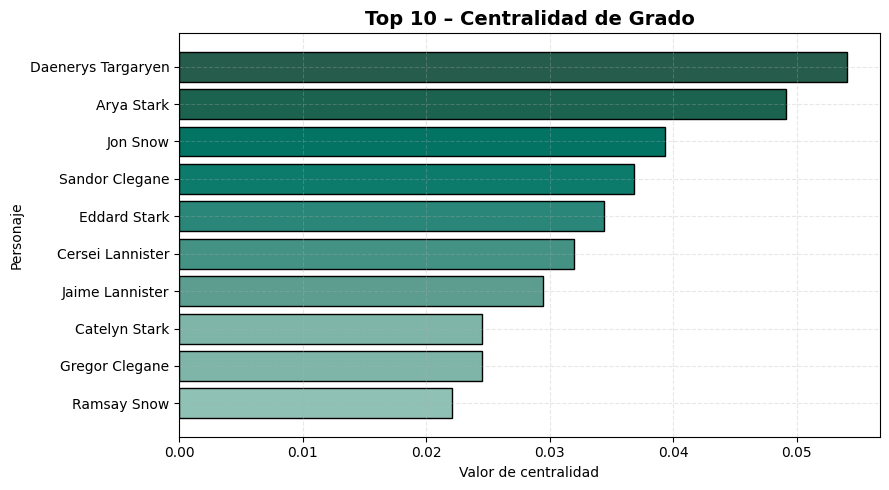

,Personaje,Valor de centralidad
0,Daenerys Targaryen,0.054054
1,Arya Stark,0.049140
2,Jon Snow,0.039312
3,Sandor Clegane,0.036855
4,Eddard Stark,0.034398
5,Cersei Lannister,0.031941
6,Jaime Lannister,0.029484
7,Catelyn Stark,0.024570
8,Gregor Clegane,0.024570
9,Ramsay Snow,0.022113


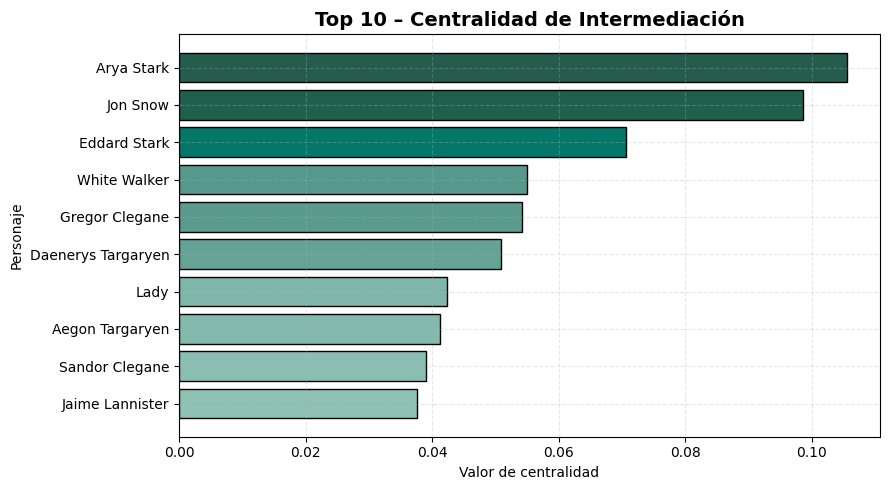

,Personaje,Valor de centralidad
0,Arya Stark,0.105526
1,Jon Snow,0.098658
2,Eddard Stark,0.070674
3,White Walker,0.054994
4,Gregor Clegane,0.054228
5,Daenerys Targaryen,0.050844
6,Lady,0.042386
7,Aegon Targaryen,0.041174
8,Sandor Clegane,0.039022
9,Jaime Lannister,0.037597


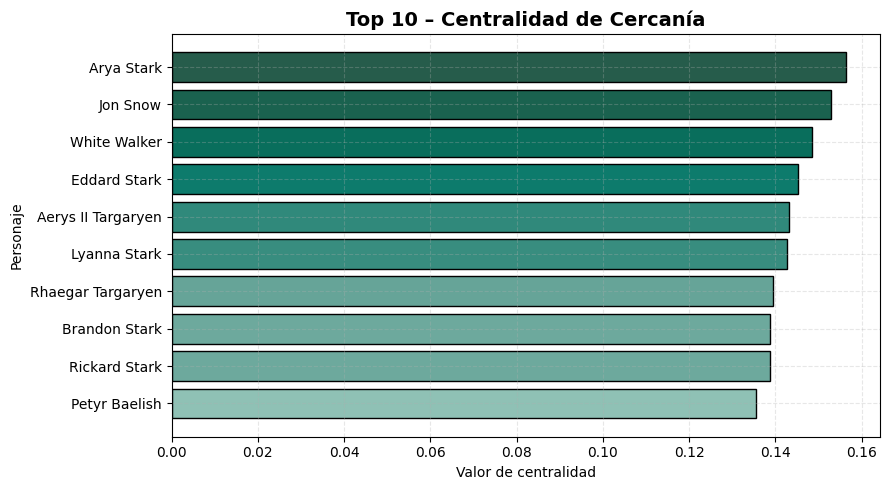

,Personaje,Valor de centralidad
0,Arya Stark,0.156446
1,Jon Snow,0.152921
2,White Walker,0.148462
3,Eddard Stark,0.145285
4,Aerys II Targaryen,0.143241
5,Lyanna Stark,0.142739
6,Rhaegar Targaryen,0.139480
7,Brandon Stark,0.138846
8,Rickard Stark,0.138846
9,Petyr Baelish,0.135610


In [50]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Paleta personalizada de verde oscuro a verde claro ---
colores_paleta = ["#265C4B", "#146551", "#007566", "#589A8D", "#8FC1B5"]
verde_gradiente = LinearSegmentedColormap.from_list("verde_gradiente", colores_paleta[::-1])

# --- Función para graficar el top 10 ---
def graficar_top10(metrica, titulo):
    top10 = sorted(metrica.items(), key=lambda x: x[1], reverse=True)[:10]
    nombres = [n for n, _ in top10]
    valores = [v for _, v in top10]

    # Normalizamos los valores para mapearlos al gradiente
    norm_vals = (valores - np.min(valores)) / (np.max(valores) - np.min(valores))
    colores = [verde_gradiente(v) for v in norm_vals]

    plt.figure(figsize=(9, 5))
    plt.title(titulo, fontsize=14, fontweight="bold")
    plt.barh(nombres[::-1], valores[::-1], color=colores[::-1], edgecolor='black')
    plt.xlabel("Valor de centralidad")
    plt.ylabel("Personaje")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

    # Mostrar tabla con valores
    df = pd.DataFrame({"Personaje": nombres, "Valor de centralidad": valores})
    display(df)

# --- Visualización de las tres métricas con tu paleta ---
graficar_top10(centralidad_grado, "Top 10 – Centralidad de Grado")
graficar_top10(centralidad_betweenness, "Top 10 – Centralidad de Intermediación")
graficar_top10(centralidad_closeness, "Top 10 – Centralidad de Cercanía")


En lugar de emplear paletas multicolor, se ha optado por un color único con variaciones de intensidad, de modo que el tono más oscuro representa el valor de centralidad más alto.

Este enfoque facilita la lectura y mantiene una correspondencia visual intuitiva entre importancia e intensidad, evitando interpretaciones erróneas derivadas de cambios de tono.

**3. Realiza una nueva visualización en la que el tamaño del nodo represente la importancia del personaje según la métrica que consideras que muestra mejor los personajes más importantes de la historia.** 

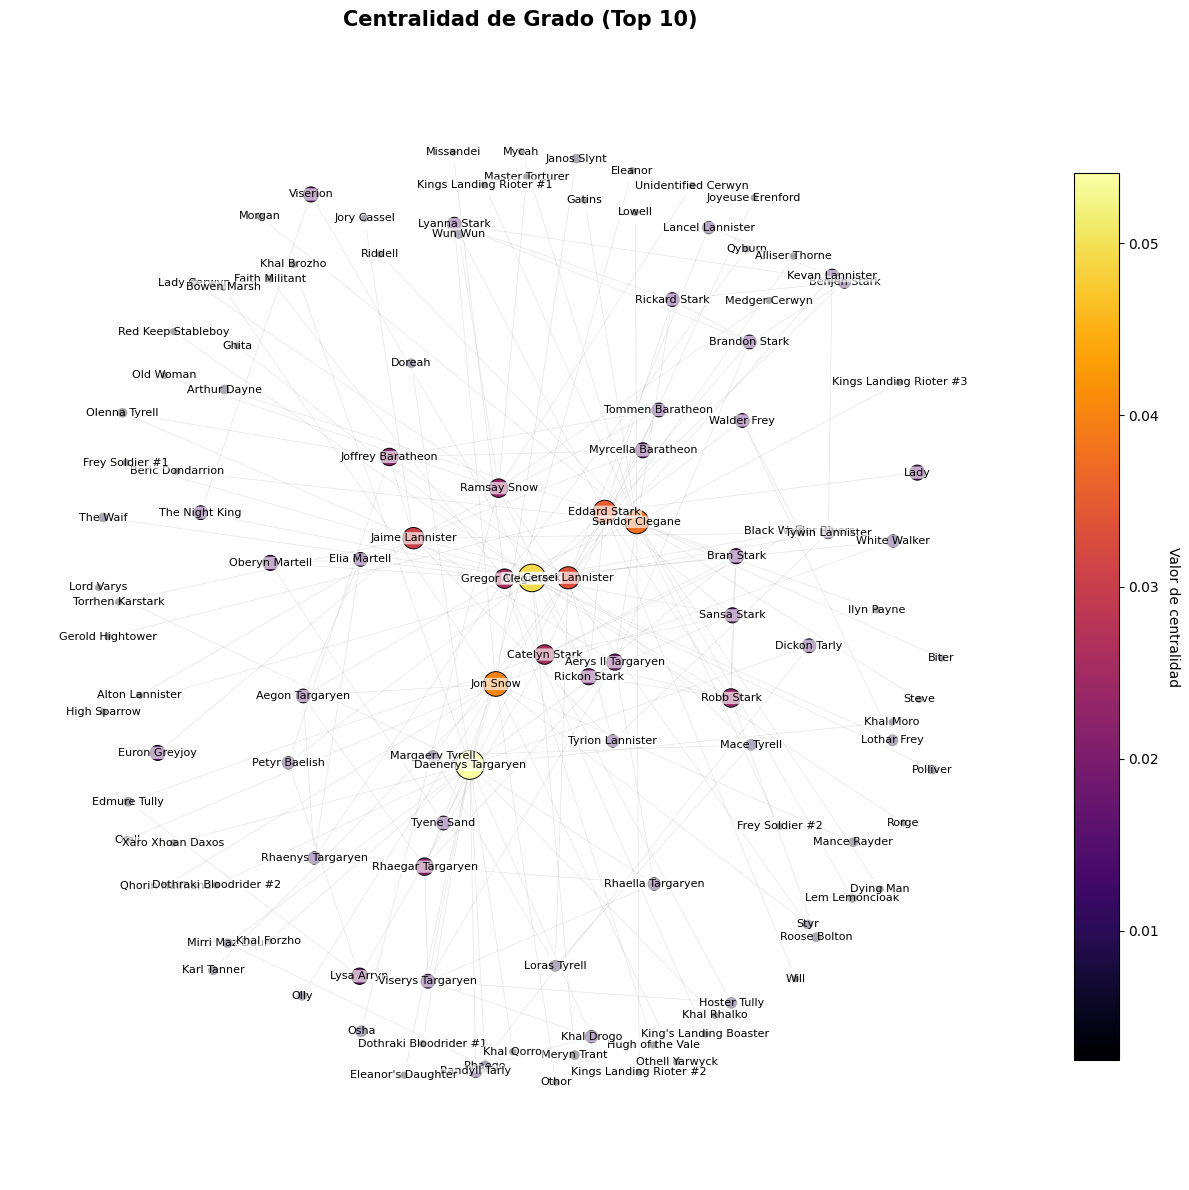

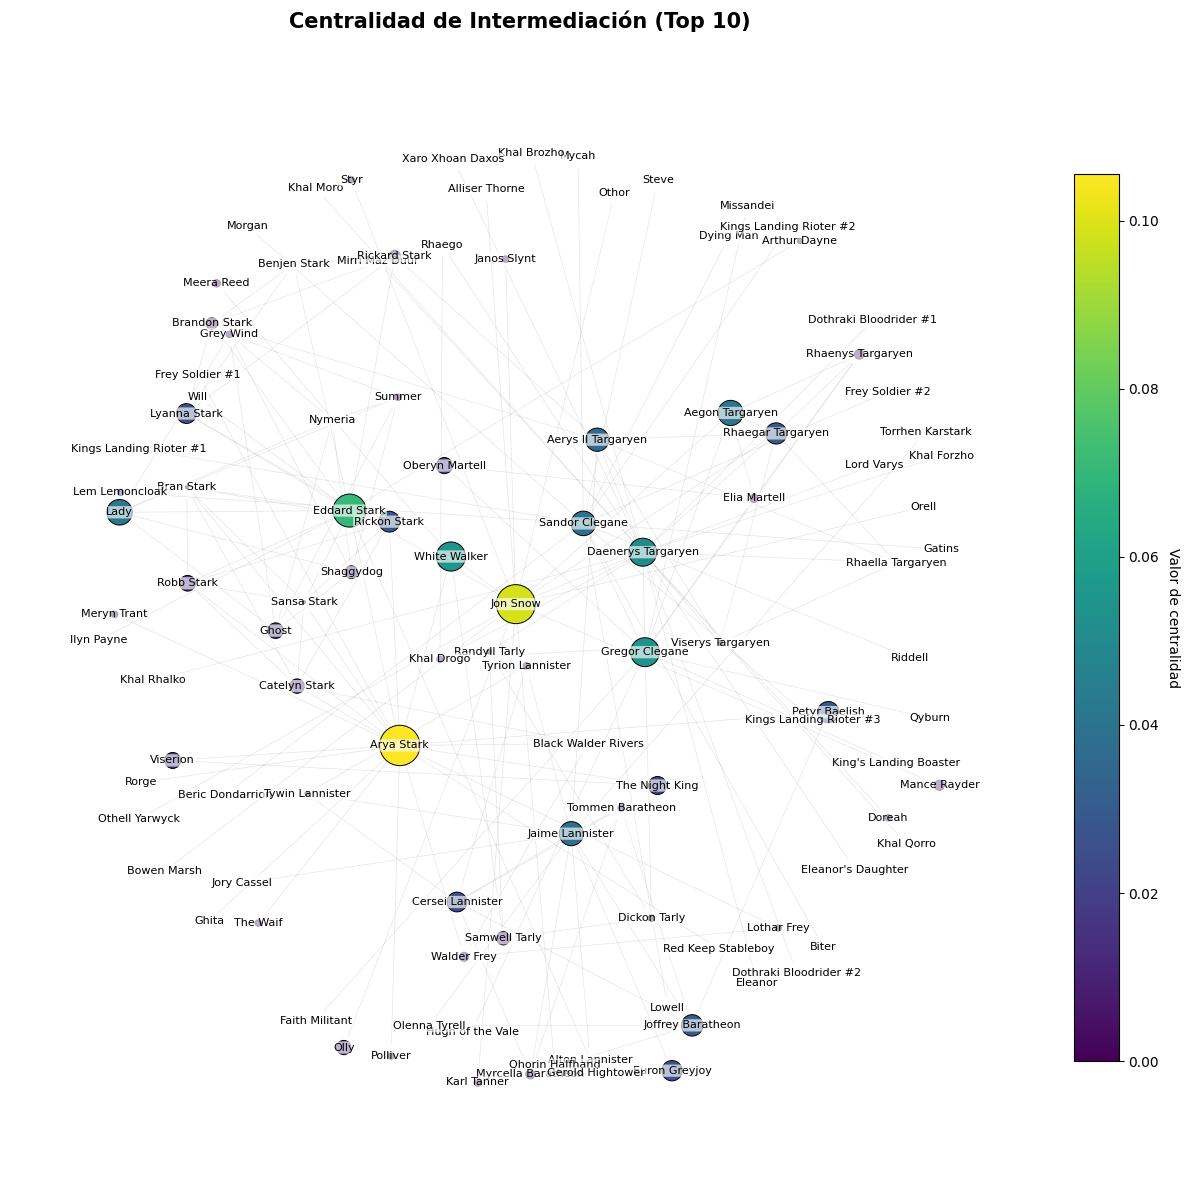

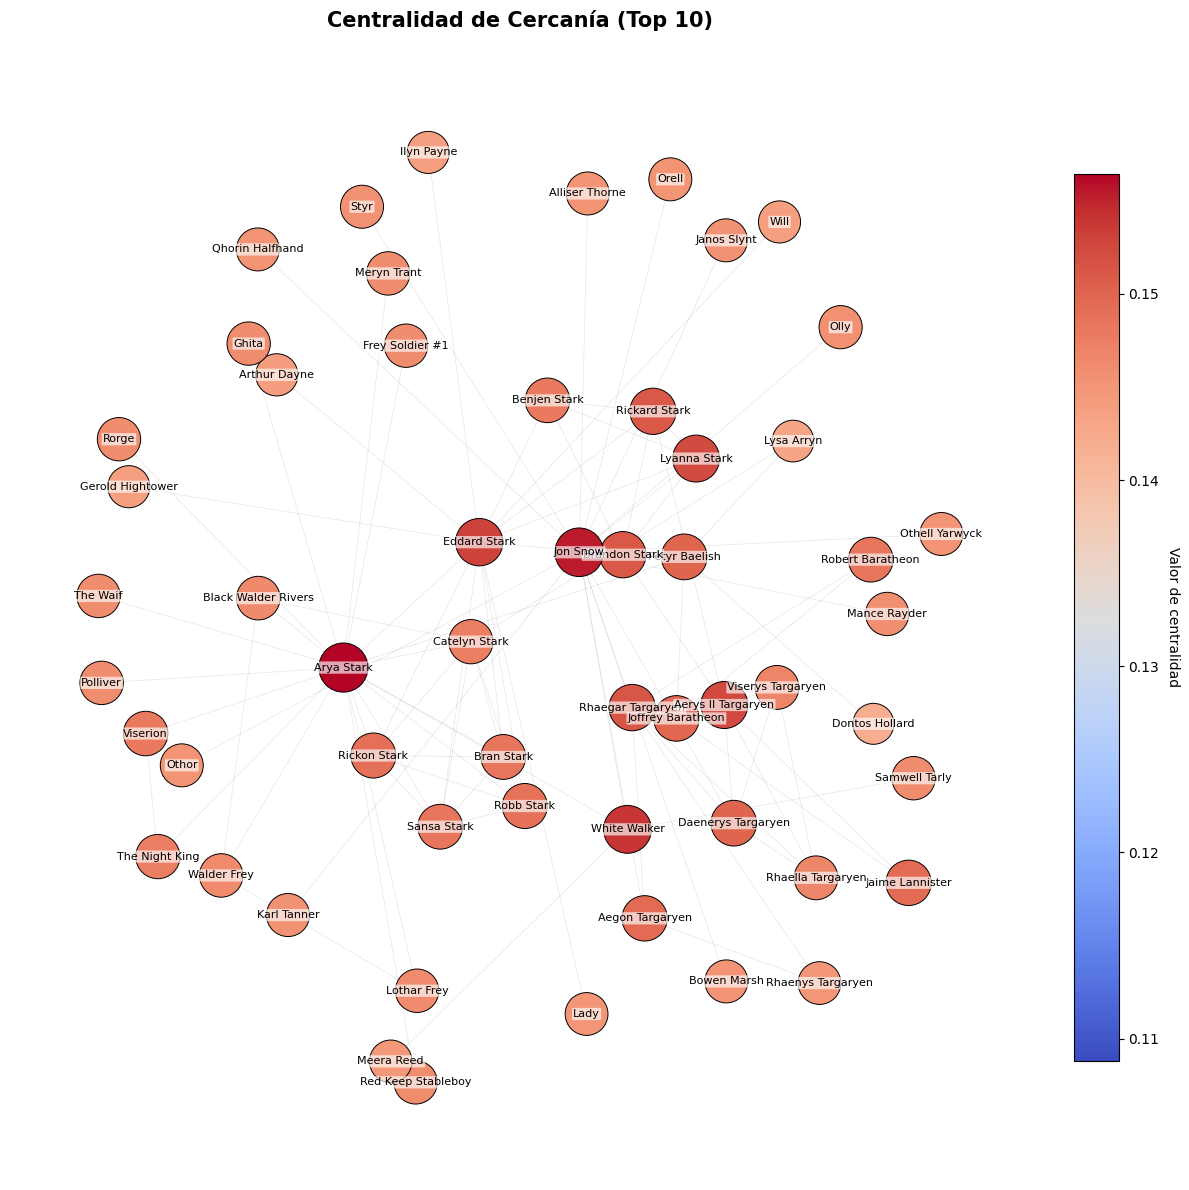

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# === VISUALIZACIÓN DE CENTRALIDAD CON MAPA DE CALOR (TOP 10) ===

def visualizar_centralidad(G, centralidad, titulo, cmap):
    # Ordenamos y seleccionamos top 10
    top10 = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
    top_nodes = [n for n, _ in top10]

    # Subgrafo con los 10 principales + vecinos
    nodos_relacionados = set(top_nodes)
    for n in top_nodes:
        nodos_relacionados.update(G.neighbors(n))
    subG = G.subgraph(nodos_relacionados)

    # Layout con más separación
    pos_sub = nx.spring_layout(subG, k=0.8, seed=42)

    # Normalización de valores
    valores_nodos = [centralidad.get(n, 0) for n in subG.nodes()]
    max_val = max(valores_nodos) if max(valores_nodos) > 0 else 1
    colores = plt.cm.get_cmap(cmap)([v / max_val for v in valores_nodos])
    tamaños = [8000 * v for v in valores_nodos]

    # --- Crear figura ---
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.set_title(titulo, fontsize=15, fontweight="bold", pad=20)

    # Dibujar aristas
    nx.draw_networkx_edges(subG, pos_sub, alpha=0.2, edge_color="gray", arrows=True, width=0.5, ax=ax)

    # Dibujar nodos (más visibles)
    nx.draw_networkx_nodes(
        subG, pos_sub,
        node_color=colores,
        node_size=tamaños,
        edgecolors="black",  # bordes negros para mejor contraste
        linewidths=0.7,
        ax=ax
    )

    # Etiquetas: más grandes y con fondo blanco translúcido
    nx.draw_networkx_labels(
        subG, pos_sub,
        font_size=8,
        font_color="black",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", boxstyle="round,pad=0.1"),
        ax=ax
    )

    # Barra de color (más grande y mejor colocada)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(valores_nodos), vmax=max_val))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.04)
    cbar.set_label("Valor de centralidad", rotation=270, labelpad=15, fontsize=10)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- Aplicar a cada métrica ---
visualizar_centralidad(G, centralidad_grado, "Centralidad de Grado (Top 10)", "inferno")
visualizar_centralidad(G, centralidad_betweenness, "Centralidad de Intermediación (Top 10)", "viridis")
visualizar_centralidad(G, centralidad_closeness, "Centralidad de Cercanía (Top 10)", "coolwarm")


Usar colores mas significativos

**Después de realizar el gráfico, responde brevemente:**



**• ¿Qué diferencias observas entre las distintas medidas de centralidad?** 



**• ¿Los personajes más “centrales” coinciden con los más importantes en la historia?** 



**• ¿Cómo influye la forma de calcular la centralidad en la interpretación del grafo?** 

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 3: Subredes y comunidades  
</div>

**En este apartado se explorará la estructura interna de la red mediante el análisis de subgrupos de personajes.** 

**1. Crea subgrafos a partir de uno o varios tipos de relación (por ejemplo, solo relaciones familiares o solo relaciones de conflicto).** 

SE  CREARA UN GRAFO MAS PEQUEÑO POR EJEMPLO RELACIONES FAMILAIRES, MATAR A ALGUIEN 

**2. Aplica un algoritmo de detección de comunidades de las que ofrece la librería NetworkX para identificar grupos dentro de la red.**

**3. Realiza una visualización en la que cada comunidad aparezca con un color diferente.** 


**4. Ajusta el tamaño de los nodos según su número de relaciones dentro de la comunidad seleccionada.**


Intentando hacer una visualización lo mas simple posible

**Después de realizar el gráfico, responde brevemente:** 

**• ¿Cuántas comunidades principales has identificado?** 


**• ¿Coinciden estas comunidades con las casas nobles, alianzas o algún patrón que se pueda reconocer en la serie?** 

**• ¿Qué decisiones de diseño (colores, tamaño, layout) te han ayudado a mejorar la 
legibilidad del grafo?**